In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.signal import wiener
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
import cv2
from scipy.signal import wiener, convolve2d

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [3]:
nu = 0.02
#nx = ny = 0.5
dt = 0.001

In [4]:
sigma, ns, sz = 4.3, 1, 7
num_steps = 1000 #4300  # 400
p = 100 # 40

rank = 10
dt = 1/num_steps

In [5]:
pth = "//files.ad.ife.no/MatPro_files/Florian/Burgers/"
#pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/data/burgers/"
#num_steps = 200
#p = 20
snapshot = np.load(pth+"1fine_snapshot01.npy")
n = snapshot.size
X_all = np.zeros((n, num_steps))
t_all = np.linspace(0, 1, num_steps, endpoint=False)

print(n, n**.5)
dx = dy = 1/(n**.5)
print(sigma*dx)
for i in range(0, num_steps, 1):
    print(i, end=", ")
    X_all[:, i] = np.load(pth+"1fine_snapshot{:02d}.npy".format(i))

66049 257.0
0.016731517509727626
0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 21

# smooth ROM, guessed parameters

In [6]:
shape = int(n**.5), int(n**.5)
X_train = X_all[:, ::p]
t_train = t_all[::p]
X_train_s = np.zeros_like(X_train)
for i in range(len(X_train[0])):
    ss2D = X_train[:, i].reshape(shape)
    X_train_s[:, i] = gaussian_filter(ss2D, sigma=sigma, truncate=12).ravel()
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(2, 1))
#     ax1.imshow(X_train[:, i].reshape(shape), interpolation="nearest", cmap="plasma", origin="lower")
#     ax2.imshow(X_train_s[:, i].reshape(shape), interpolation="nearest", cmap="plasma", origin="lower")
#     plt.show()

In [7]:
U, S, VT = np.linalg.svd(X_train, False)
U_c, S_c, VT_c = np.linalg.svd(X_train_s, False)

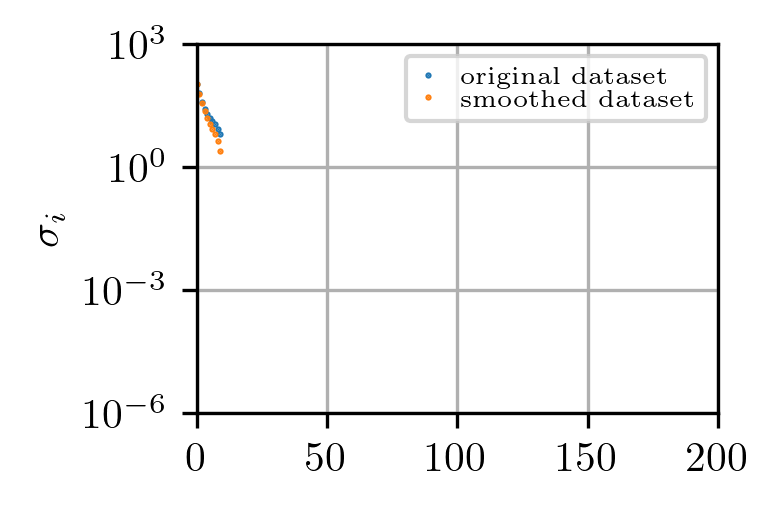

In [8]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(S, ".", ms=1, label="original dataset")
ax.plot(S_c, ".", ms=1, label="smoothed dataset")
ax.set_yscale('log')
ax.set_xlim([0, 200])
ax.set_ylim([1e-6, 1000])
plt.ylabel("$\sigma_i$")
plt.legend()
plt.grid()

In [9]:
print(X_train.shape, t_train[:, None].shape)

(66049, 10) (10, 1)


In [10]:
inds = np.random.randint(0, np.int32(num_steps*0.9), 20)
xi_test = t_all[inds, None]
print(inds, xi_test)
ground_truth = np.zeros((X_all.shape[0], len(xi_test)))
for i in range(len(xi_test)):
    ind = np.where((t_all-xi_test[i])**2<1e-6)[0][0]
    ground_truth[:, i] = X_all[:, ind]

[892  35 134 502  57 559 174 582 516 116  10 856 776 418 859 482 320 360
 706 894] [[0.892]
 [0.035]
 [0.134]
 [0.502]
 [0.057]
 [0.559]
 [0.174]
 [0.582]
 [0.516]
 [0.116]
 [0.01 ]
 [0.856]
 [0.776]
 [0.418]
 [0.859]
 [0.482]
 [0.32 ]
 [0.36 ]
 [0.706]
 [0.894]]


# standard ROM

In [11]:
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(t_train[:, None], X_train.T)
rom = ROM(db, pod, reg)
rom.fit()
standard_ROM = rom.predict(xi_test).T

eROM = np.mean((standard_ROM-ground_truth)**2, axis=0)**.5
print(eROM)


-0.9350660058354305 0.8543986438675992
(66049, 20)
0.026091914589048783


[0.892]


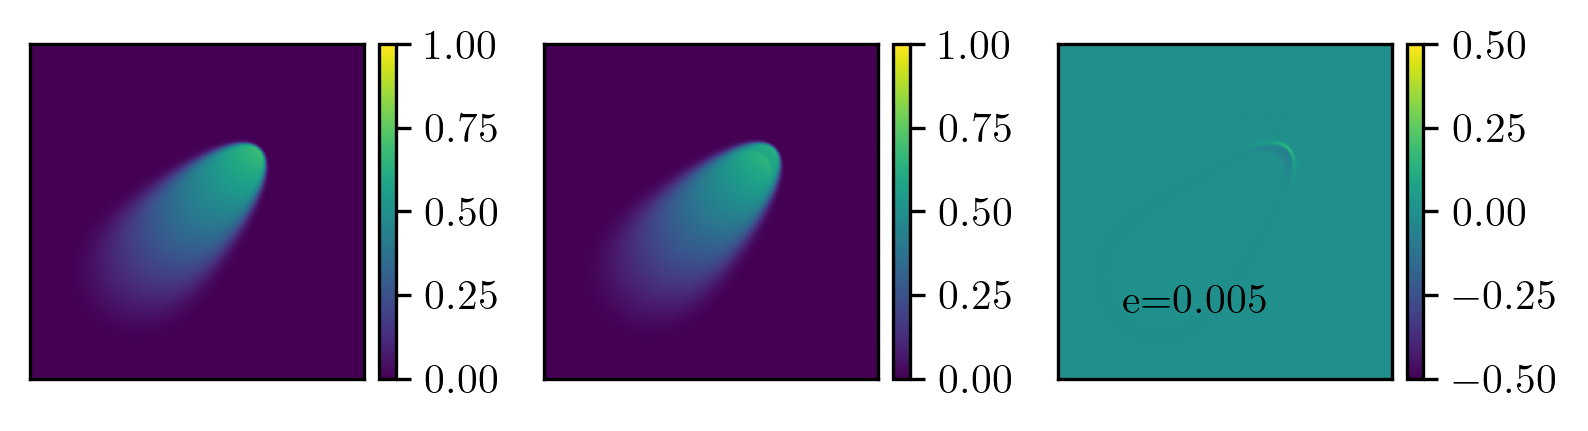

[0.035]


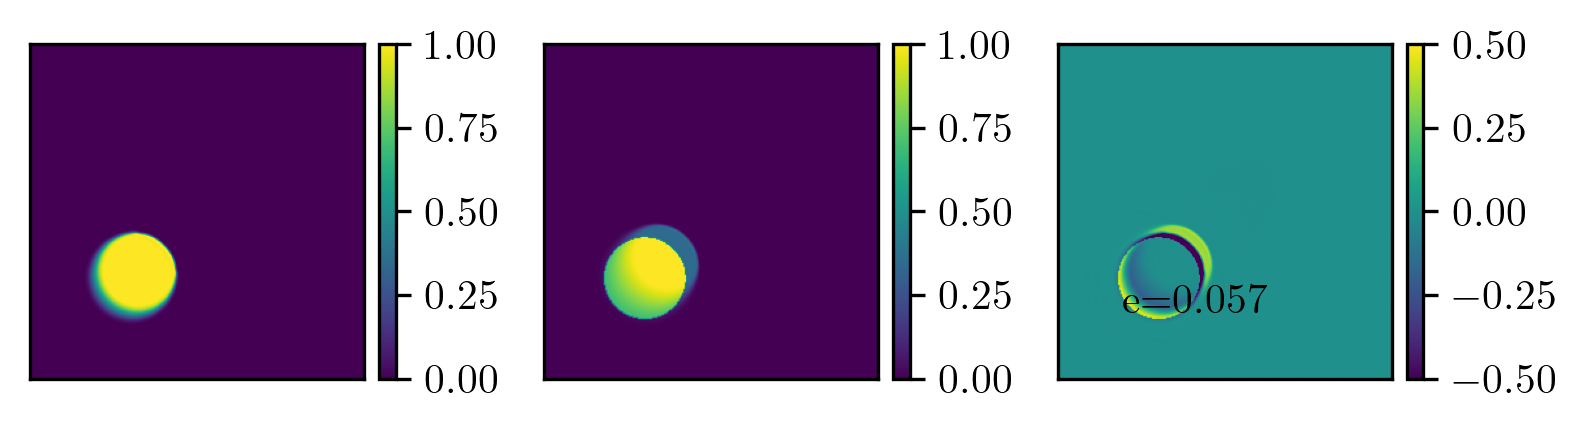

[0.134]


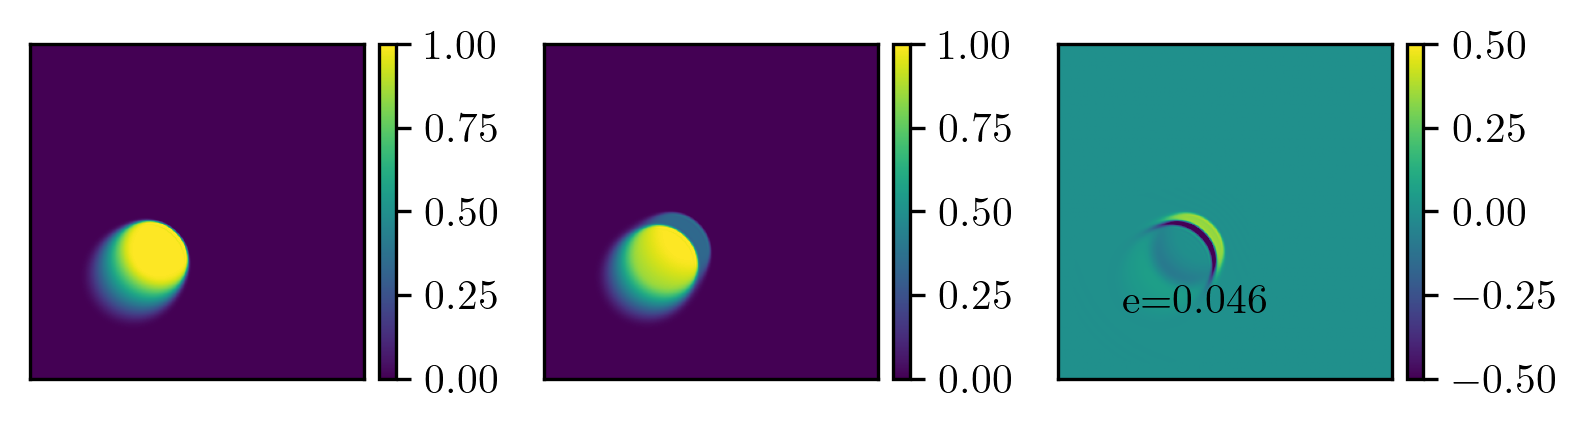

[0.502]


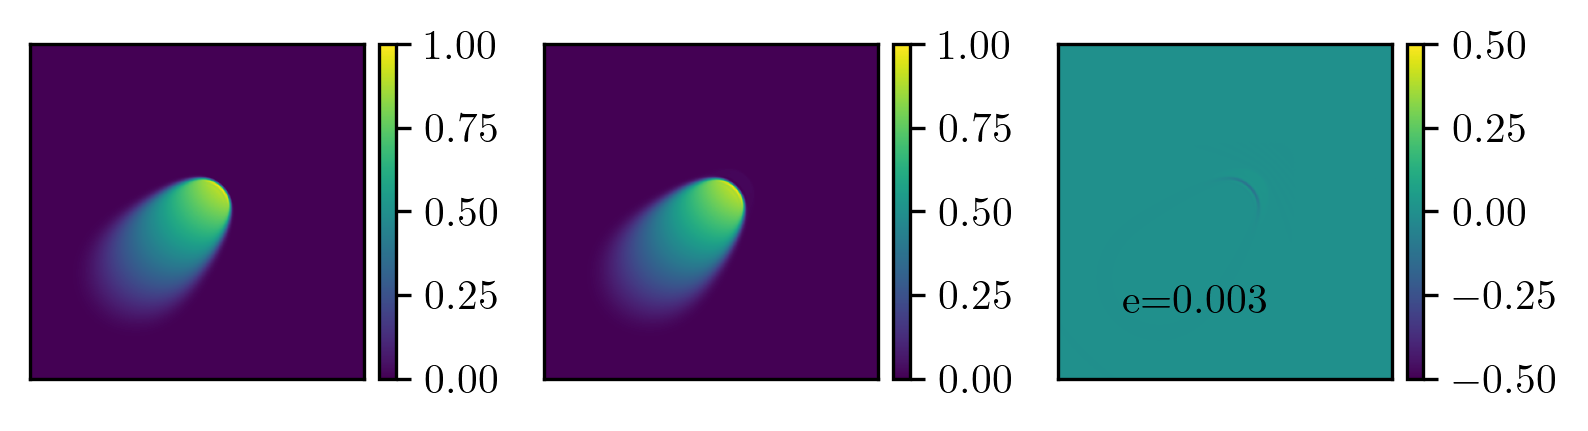

[0.057]


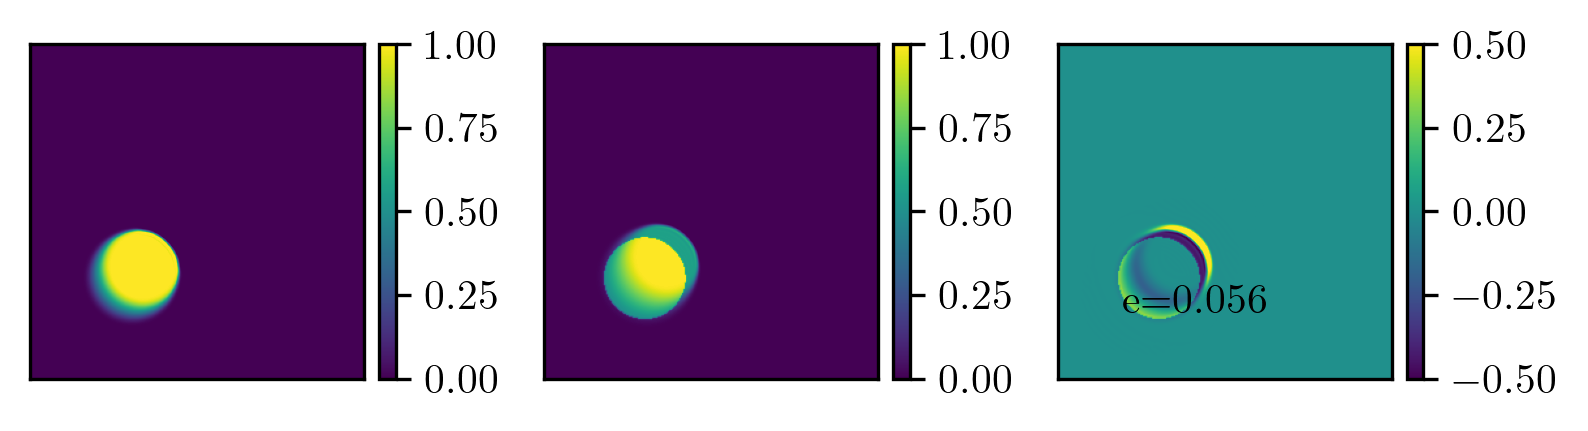

[0.559]


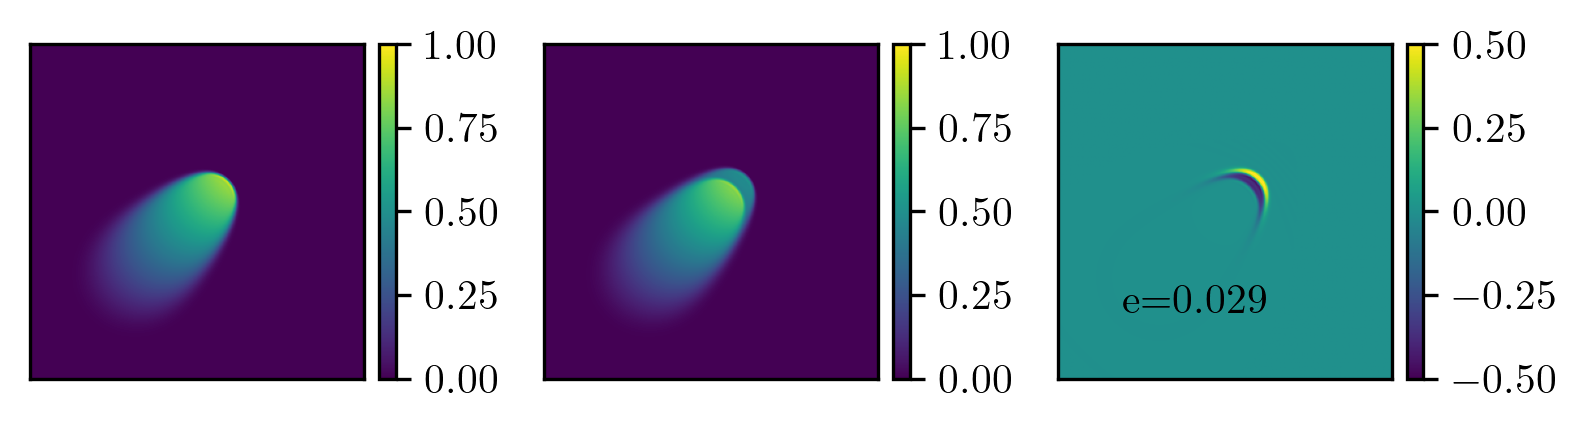

[0.174]


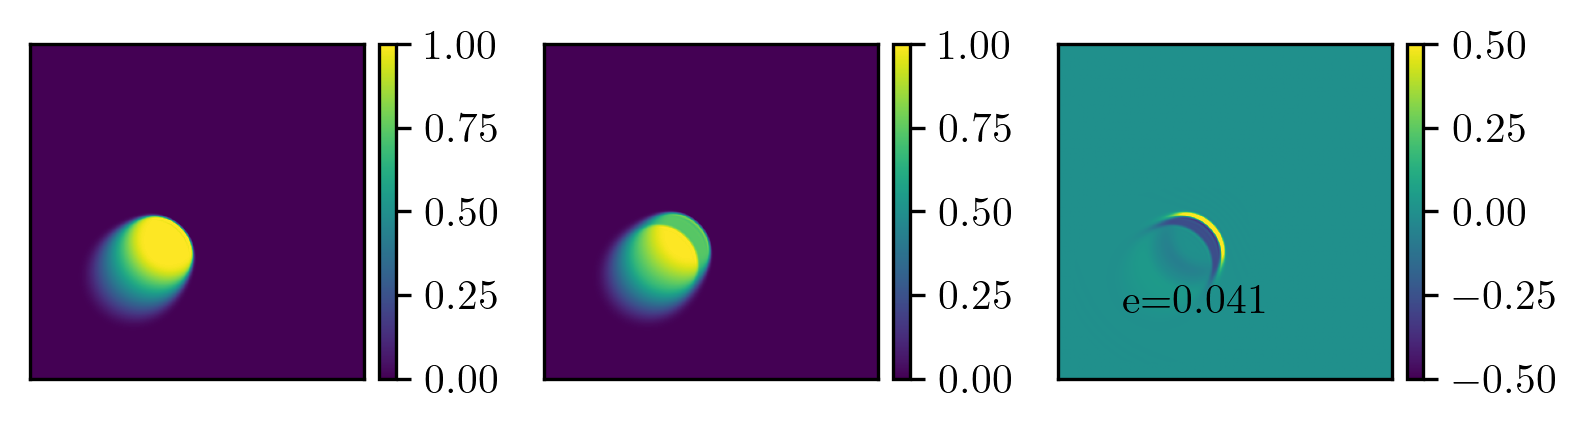

[0.582]


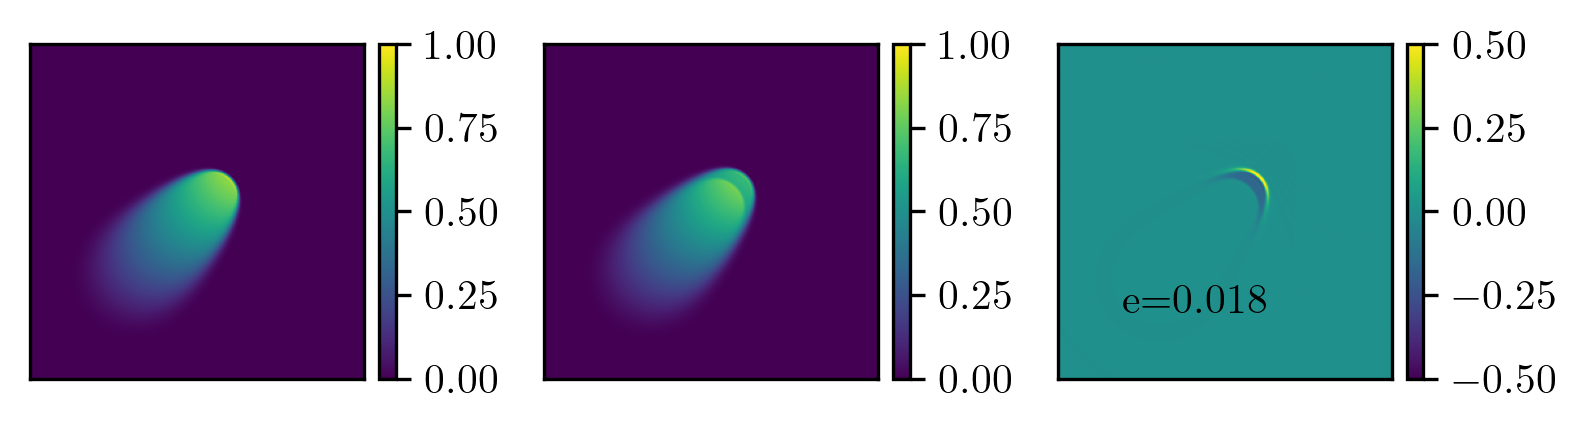

[0.516]


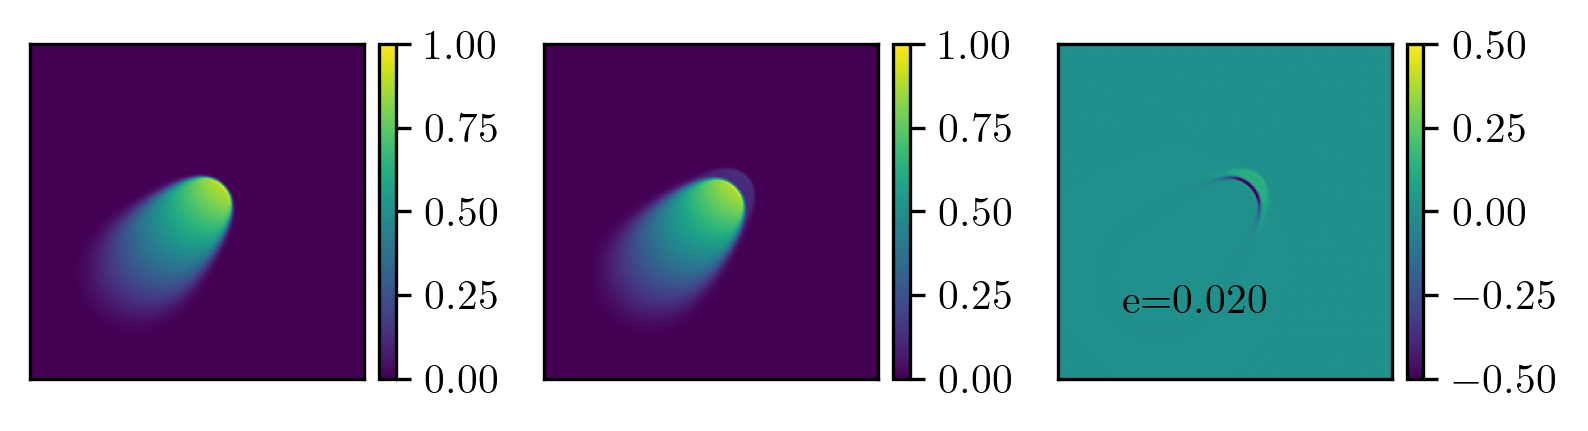

[0.116]


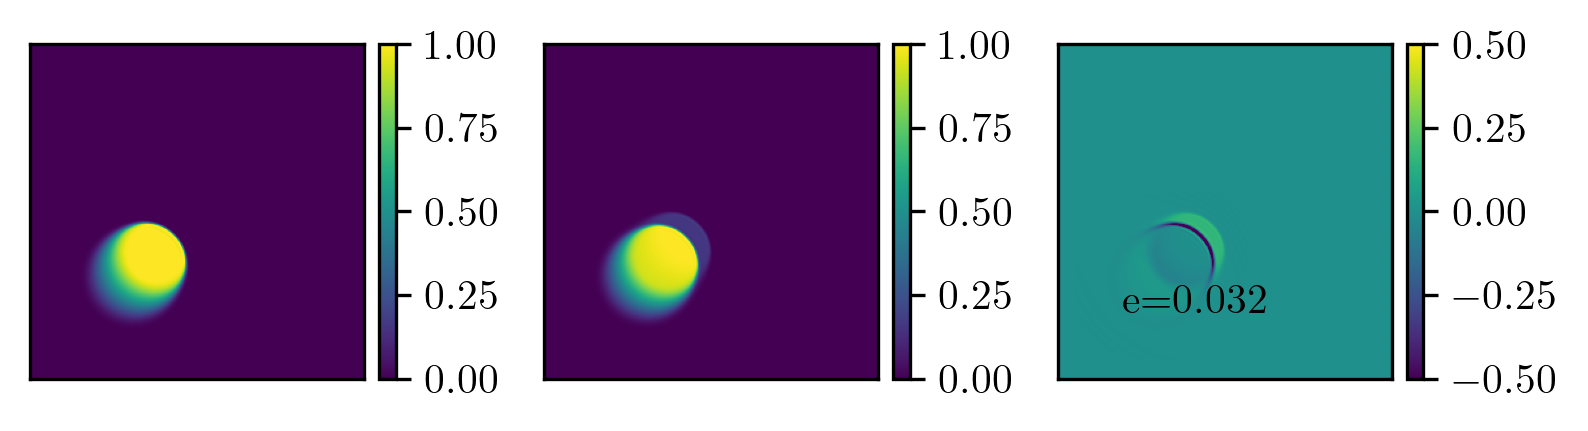

In [33]:
for i in range(len(xi_test[:10])):
    print(xi_test[i])
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(page_width_in, page_width_in/3))
    c1 = ax1.imshow(ground_truth[:, i].reshape(shape), vmin=0, vmax=1, origin="lower")
    c2 = ax2.imshow(standard_ROM[:, i].reshape(shape), vmin=0, vmax=1, origin="lower")
    c3 = ax3.imshow((standard_ROM[:, i]-ground_truth[:, i]).reshape(shape), vmin=-.5, vmax=.5, origin="lower")
    ax3.text(50, 50, "e={:.3f}".format(np.mean((standard_ROM[:, i]-ground_truth[:, i])**2)**.5))
    for ax, cs in zip([ax1, ax2, ax3], [c1, c2, c3]):
        ax.set_xticks([])
        ax.set_yticks([])
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        fig.colorbar(cs, cax=cax)
    plt.show()

# smooth ROM

In [44]:
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(t_train[:, None], X_train_s.T)
rom = ROM(db, pod, reg)
rom.fit()
smooth_ROM = rom.predict(xi_test).T

e2 = smooth_ROM-ground_truth
e2 = np.mean((smooth_ROM-ground_truth)**2, axis=0)**.5
print(e2)

[0.01568927 0.04999285 0.04233292 0.0228457  0.04951221 0.02773339
 0.03922522 0.02380693 0.02512431 0.03603127 0.04511597 0.01866926
 0.0193512  0.02972091 0.01854997 0.02761968 0.03400629 0.03873115
 0.01845506 0.0154703 ]


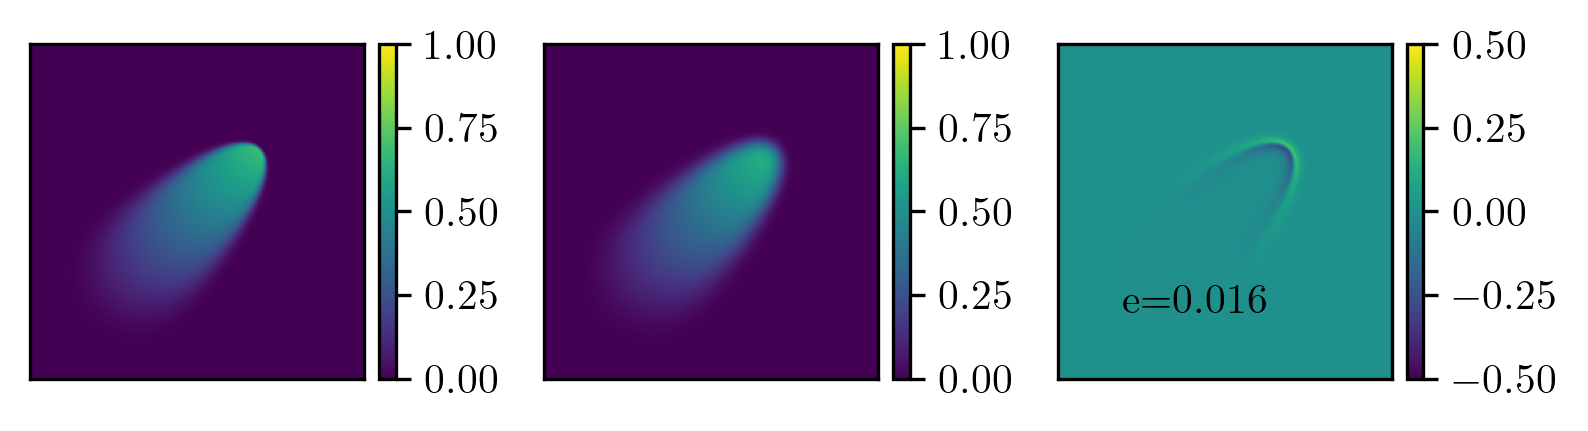

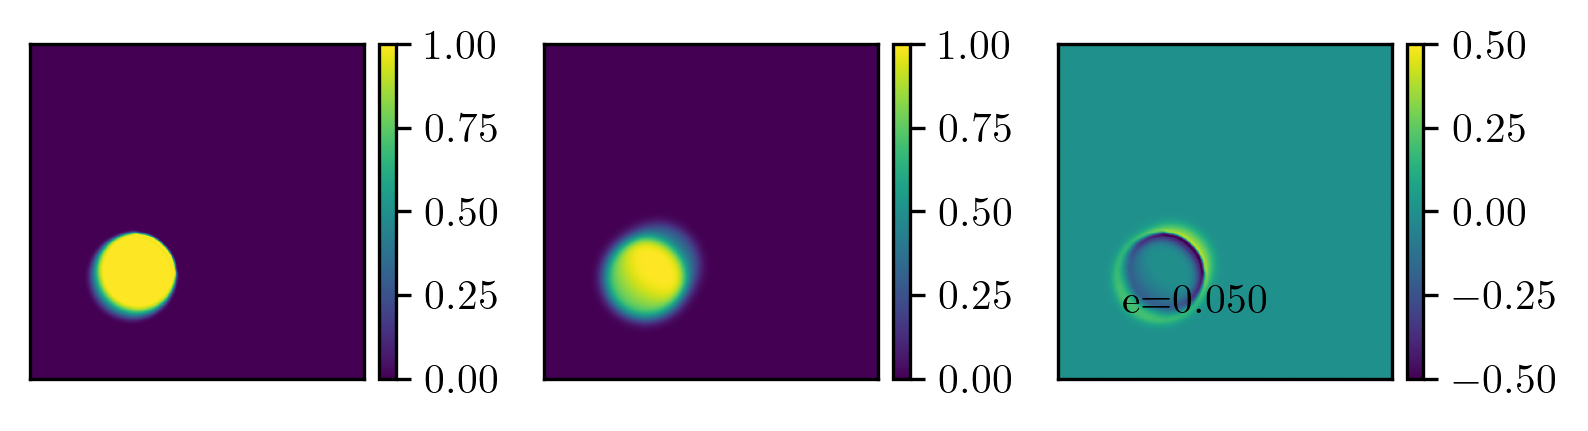

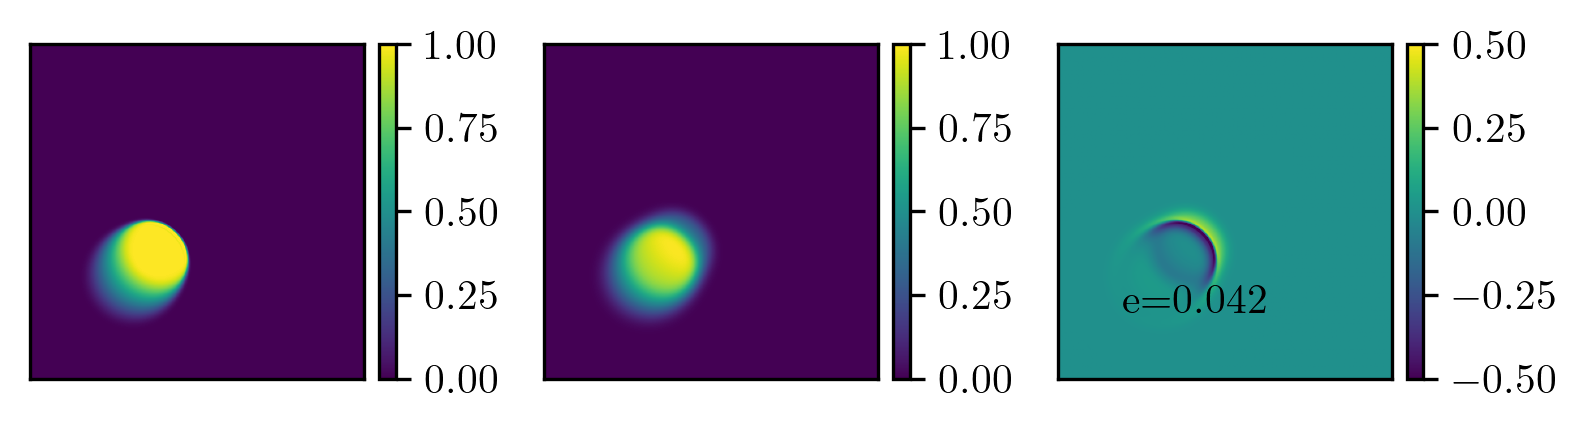

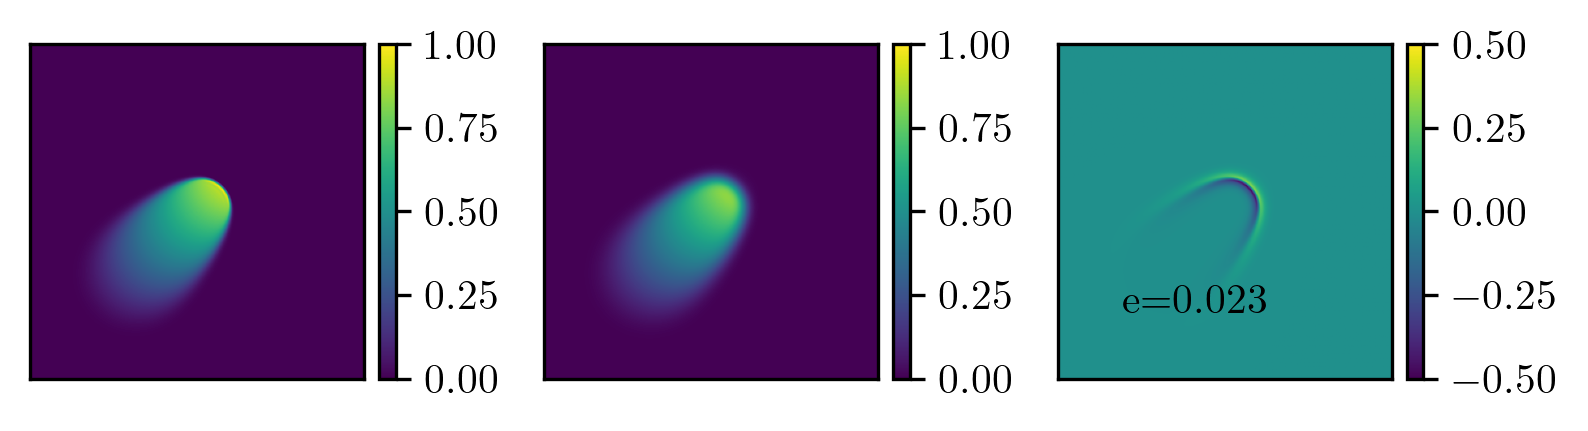

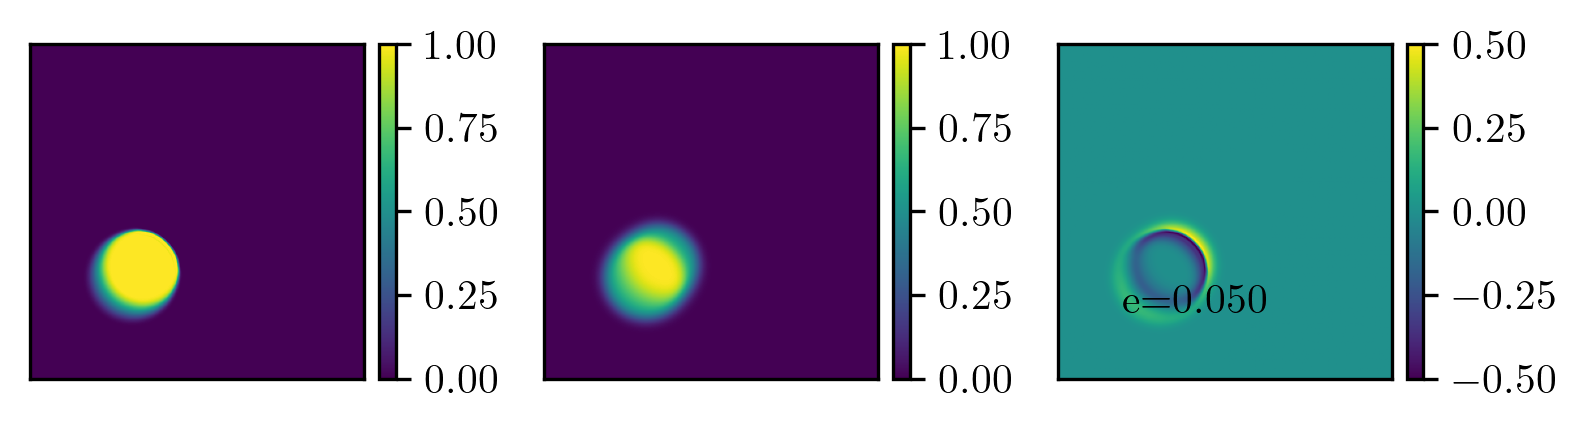

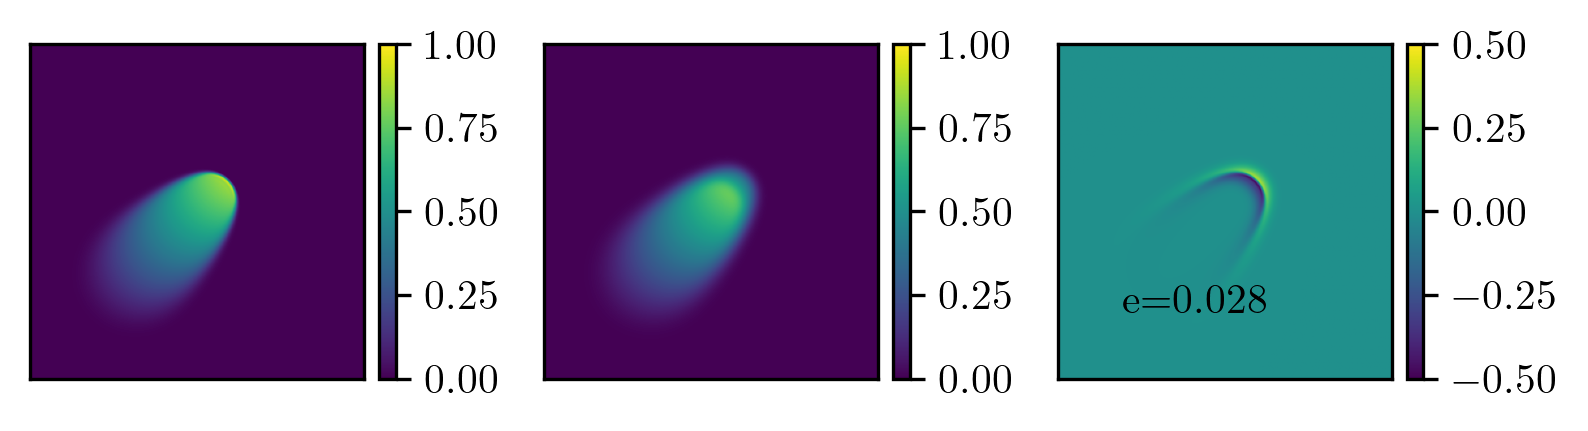

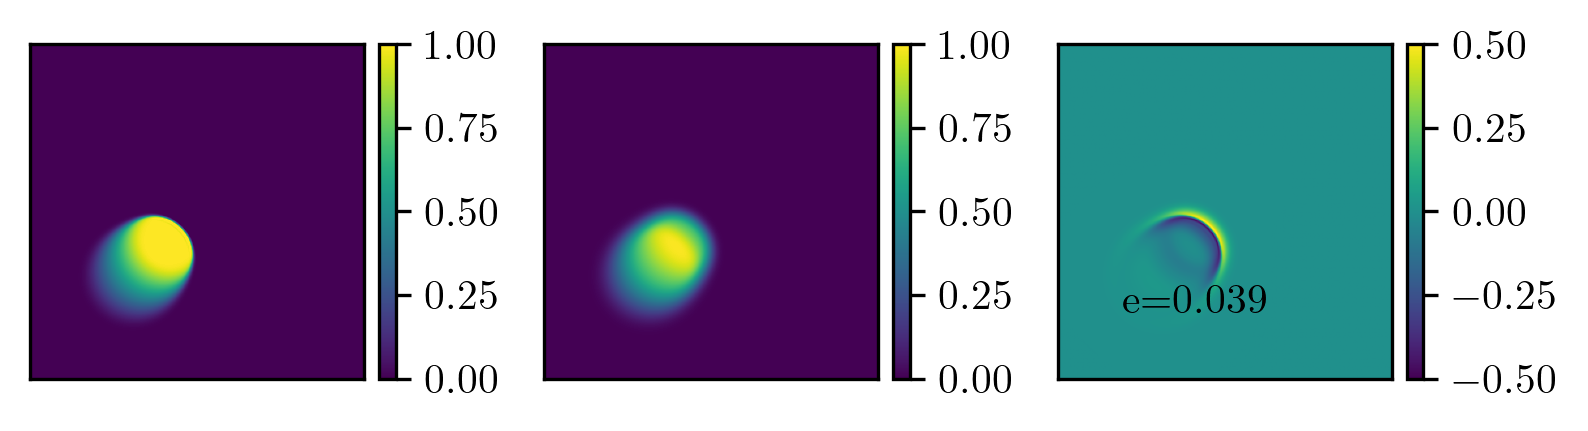

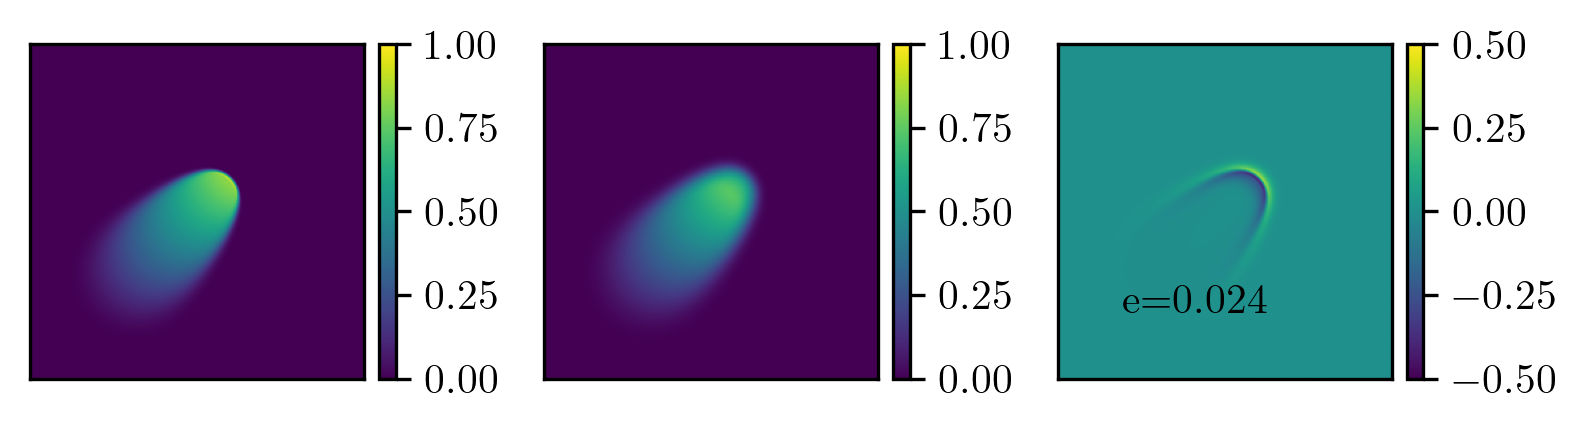

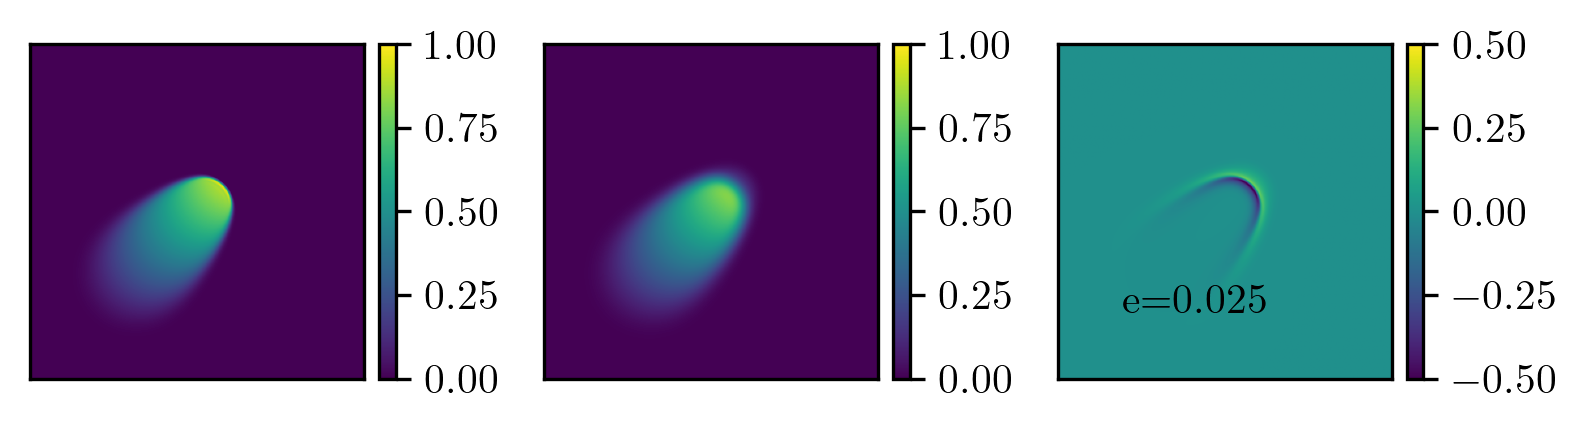

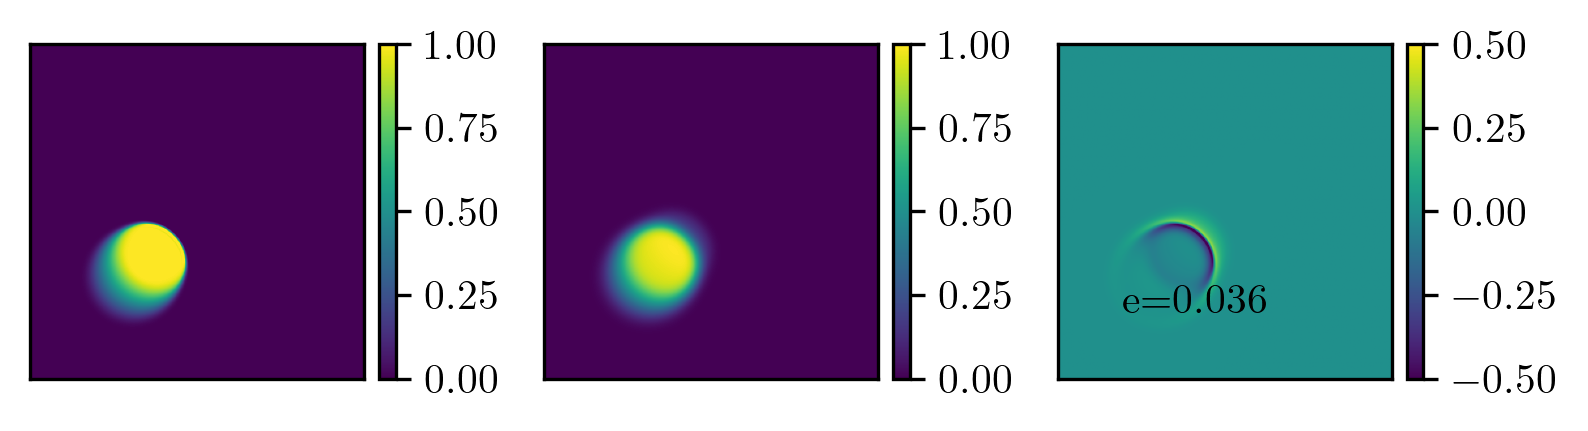

In [45]:
for i in range(len(xi_test[:10])):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(page_width_in, page_width_in/3))
    ax1.imshow(ground_truth[:, i].reshape(shape), vmin=0, vmax=1, origin="lower")
    ax2.imshow(smooth_ROM[:, i].reshape(shape), vmin=0, vmax=1, origin="lower")
    ax3.imshow((smooth_ROM[:, i]-ground_truth[:, i]).reshape(shape), vmin=-.5, vmax=.5, origin="lower")
    ax3.text(50, 50, "e={:.3f}".format(np.mean((smooth_ROM[:, i]-ground_truth[:, i])**2)**.5))
    for ax, cs in zip([ax1, ax2, ax3], [c1, c2, c3]):
        ax.set_xticks([])
        ax.set_yticks([])
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        fig.colorbar(cs, cax=cax)
    plt.show()

# smooth ROM + sharpening

In [46]:
def sharpen(data, s, ns):
    # assert s % 2 == 1, "must be odd"
    data_sharpened = data.copy()
    if s == 1:
        return data.ravel()
    elif s == 3:
        k = np.array([[0, -1, 0],
                      [-1,  5, -1],
                      [0, -1, 0]])
    elif s==5:
        k = np.array([[0, 0, -1, 0, 0],
                      [0, 0, -1, 0, 0],
                      [-1, -1,  9, -1, -1],
                      [0, 0, -1, 0, 0],
                      [0, 0, -1, 0, 0]])
    elif s==7:
        k = np.array([[0, 0, 0, -1, 0, 0, 0],
                      [0, 0, 0, -1, 0, 0, 0],
                      [0, 0, 0, -1, 0, 0, 0],
                      [-1, -1, -1,  13, -1, -1, -1],
                      [0, 0, 0, -1, 0, 0, 0],
                      [0, 0, 0, -1, 0, 0, 0],
                      [0, 0, 0, -1, 0, 0, 0]])
    elif s==9:
        k = np.array([[0, 0, 0, 0, -1, 0, 0, 0, 0],
                      [0, 0, 0, 0, -1, 0, 0, 0, 0],
                      [0, 0, 0, 0, -1, 0, 0, 0, 0],
                      [0, 0, 0, 0, -1, 0, 0, 0, 0],
                      [-1, -1, -1, -1,  17, -1, -1, -1, -1],
                      [0, 0, 0, 0, -1, 0, 0, 0, 0],
                      [0, 0, 0, 0, -1, 0, 0, 0, 0],
                      [0, 0, 0, 0, -1, 0, 0, 0, 0],
                      [0, 0, 0, 0, -1, 0, 0, 0, 0]])
    elif s==11:
        k = np.array([[0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                      [-1, -1, -1, -1, -1, 21, -1, -1, -1, -1, -1],
                      [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0]])
    else:
        raise ValueError("unknown size s ={:.0f}".format(s))
    for i in range(ns):
        data_sharpened = convolve2d(data_sharpened, k,
                                    boundary='symm', mode='same')
    return data_sharpened.ravel()

In [47]:
def sharpen2(data, s, ns):
    assert s % 2 == 1, "must be odd"
    data_sharpened = data.copy()
    if s == 1:
        return data.ravel()
    else:
        k = np.diag(-np.ones(s))
        #k = np.diag(-np.abs(np.arange(-s//2, s//2)+1))
        c = s//2
        k[c, c] = 0
        k[c, c] = -np.sum(k)+1
        k = k[::-1, :]
    for i in range(ns):
        data_sharpened = convolve2d(data_sharpened, k,
                                    boundary='symm', mode='same')
    return data_sharpened.ravel()

In [56]:
def neares_neighbour(x, x_all):
    return np.min(np.abs(x-x_all))


def get_sigma(sigma, x_sample, x_test, c):
    d = neares_neighbour(x_sample, x_test)
    dx = x_test[1]-x_test[0]
    return sigma*(1+ c*d/dx)


def richardson_lucy(im_blur, sgm, num_iter=1000, clip=False, filter_epsilon=None):
    #psf_f = gaussian_f(sgm, m)
    truncate = 2
    kernel_size = int(2*truncate * sgm) + 1
    kernel1D = cv2.getGaussianKernel(kernel_size, sgm)
    psf = psf_mirror = np.outer(kernel1D, kernel1D)
    im_deconv = im_blur.copy()
    plt.plot(kernel1D)
    plt.show()

    # Small regularization parameter used to avoid 0 divisions
    eps = 1e-12

    for _ in range(num_iter):
#        convolve2d(data_sharpened, k, boundary='symm', mode='same')
        blurred = convolve2d(im_deconv, psf, boundary='symm', mode='same') + eps
        #blurred = convolve_f(im_deconv, psf_f) + eps
        if filter_epsilon:
            relative_blur = np.where(blurred < filter_epsilon, 0, im_blur / blurred)
        else:
            relative_blur = im_blur / blurred
        #print(_, np.min(relative_blur), np.max(relative_blur))
        im_deconv *= convolve2d(relative_blur, psf_mirror, boundary='symm', mode='same')
        #im_deconv *= convolve_f(relative_blur, psf_f)
        

    if clip:
        im_deconv[im_deconv > 1] = 1
        im_deconv[im_deconv < -1] = -1

    return im_deconv

def sharpen3(data, sigma, c, mu_sample, mu_train):
    sgm_est = get_sigma(sigma, mu_sample, mu_train, c=c)
    return richardson_lucy(data, sgm_est, num_iter=30)

In [69]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Burger/"
np.save(pth+"smooth_ROM.npy", smooth_ROM)
np.save(pth+"smooth_ROM_sharpened.npy", smooth_ROM_sharpened)

np.save(pth+"mu_test.npy", xi_test)
np.save(pth+"mu_train.npy", t_train)
np.save(pth+"mu_val.npy", t_all)

np.save(pth+"X_train.npy", X_train)
np.save(pth+"X_test.npy", ground_truth)
np.save(pth+"X_val.npy", X_all)

In [60]:
smooth_ROM_sharpened = np.zeros_like(ground_truth)
for i in range(len(xi_test)):
    print(i)
    data = smooth_ROM[:, i].copy().reshape(shape)
    mu_sample = xi_test[i]
    c = 1
    smooth_ROM_sharpened[:, i] = sharpen3(data, sigma, c, mu_sample, t_train).ravel()
    #smooth_ROM_sharpened[:, i] = sharpen(smooth_ROM[:, i].copy().reshape(shape), sz, ns)
e3 = np.mean((smooth_ROM_sharpened-ground_truth)**2, axis=0)**.5
print(e3)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
[0.00877251 0.04664745 0.03937345 0.0141489  0.04754296 0.02426868
 0.03434675 0.01703385 0.01807216 0.02774605 0.03004773 0.01388395
 0.01342601 0.02328363 0.0136778  0.02088143 0.02789664 0.0370485
 0.01079847 0.00851454]


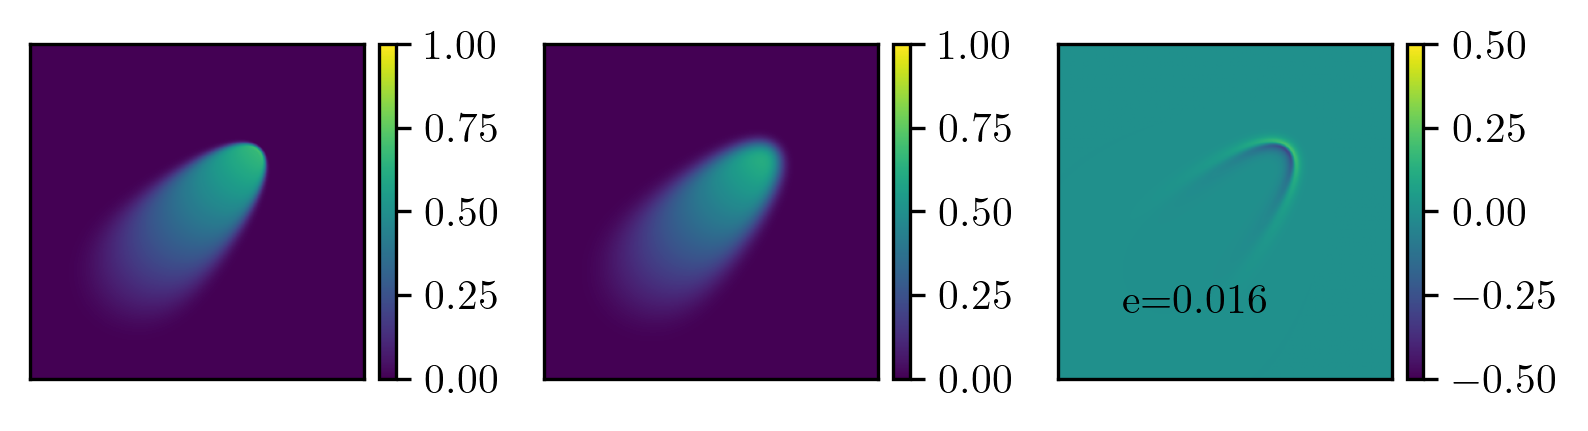

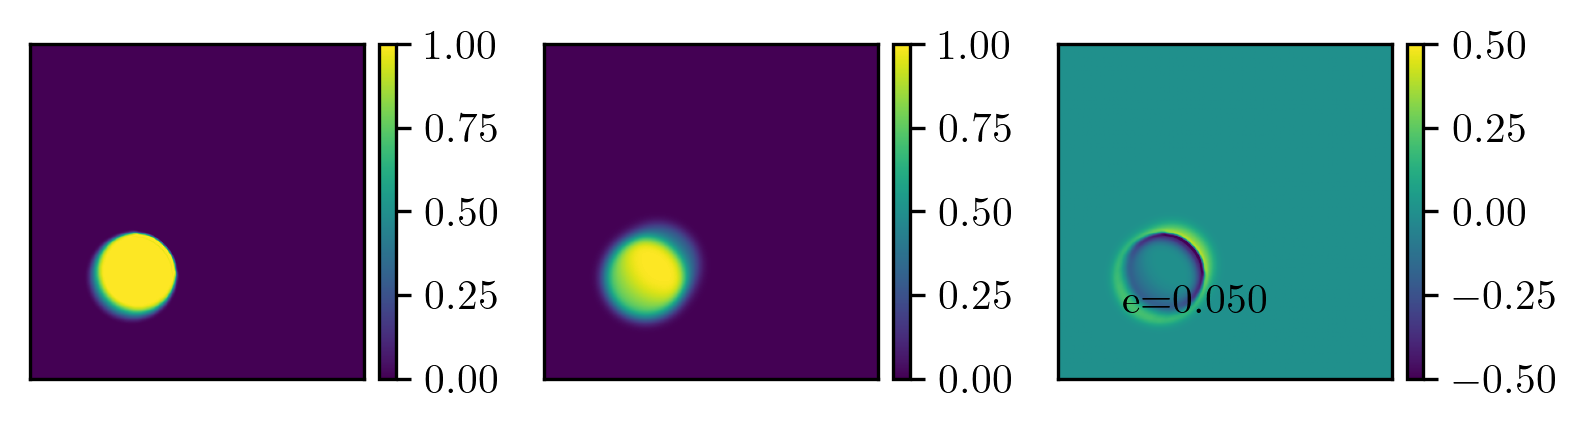

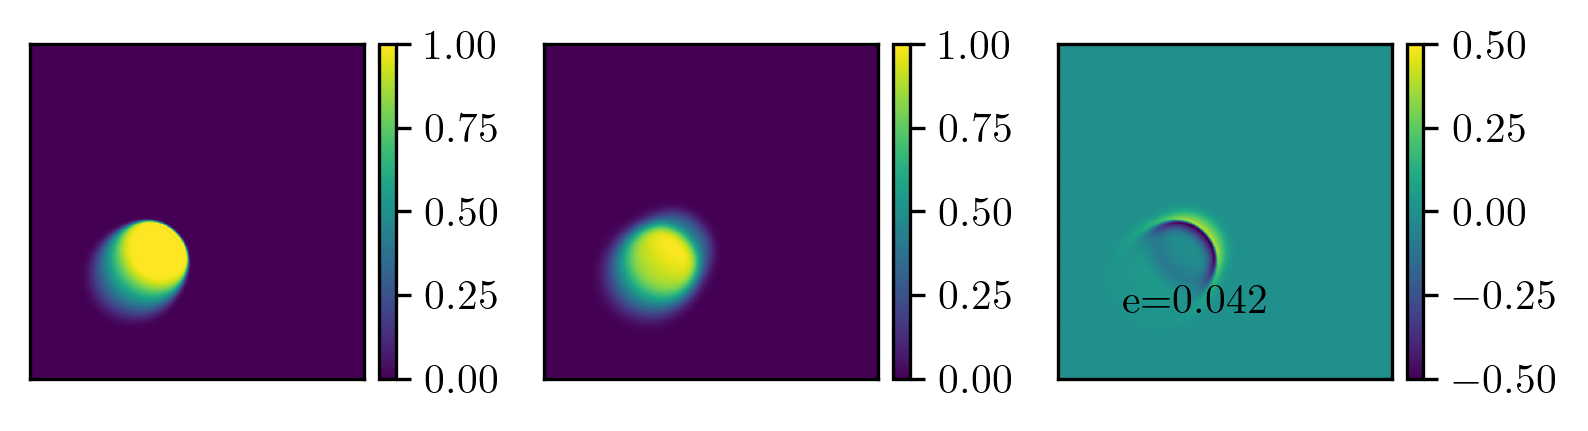

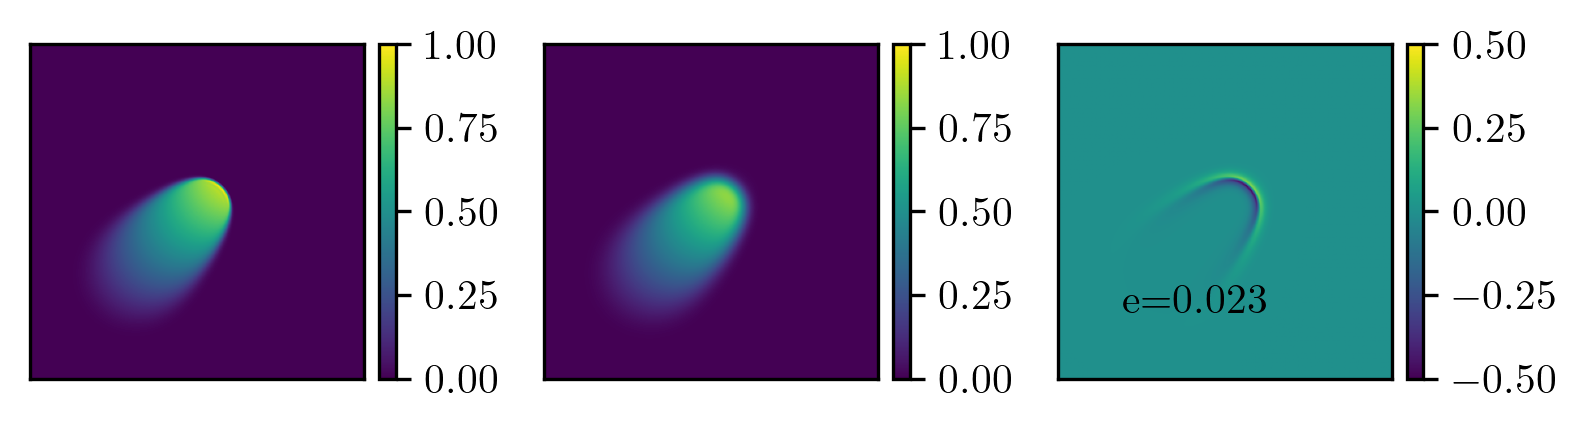

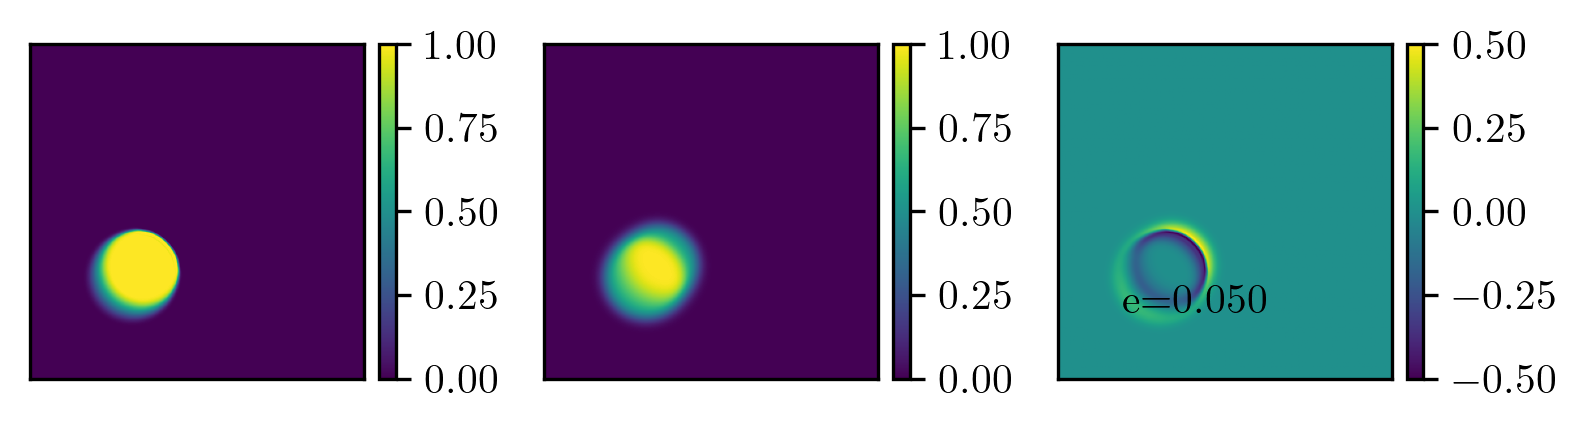

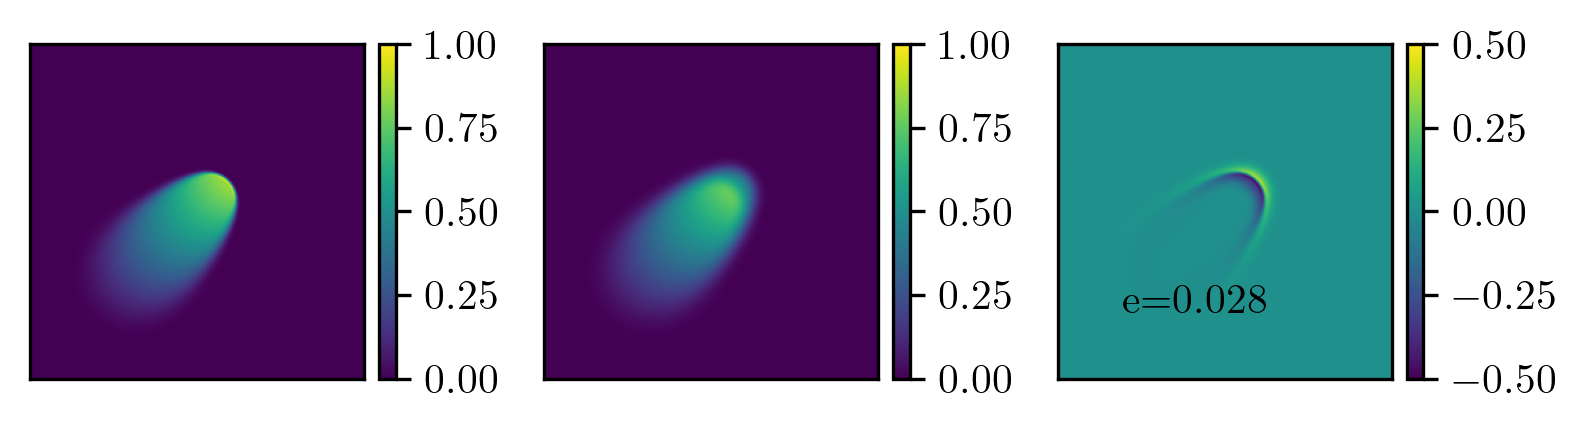

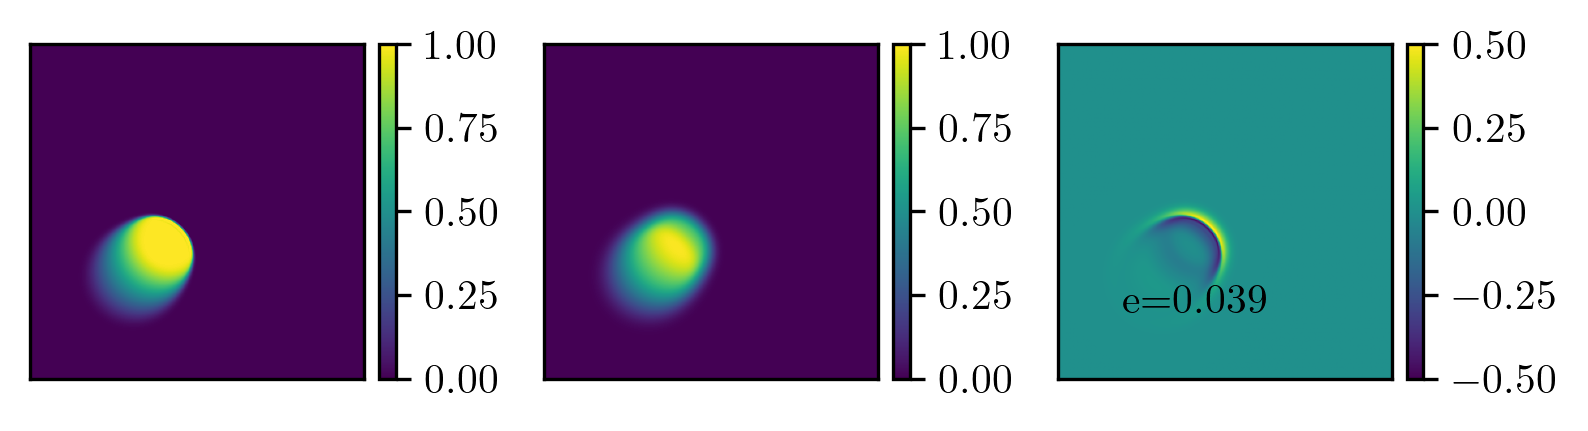

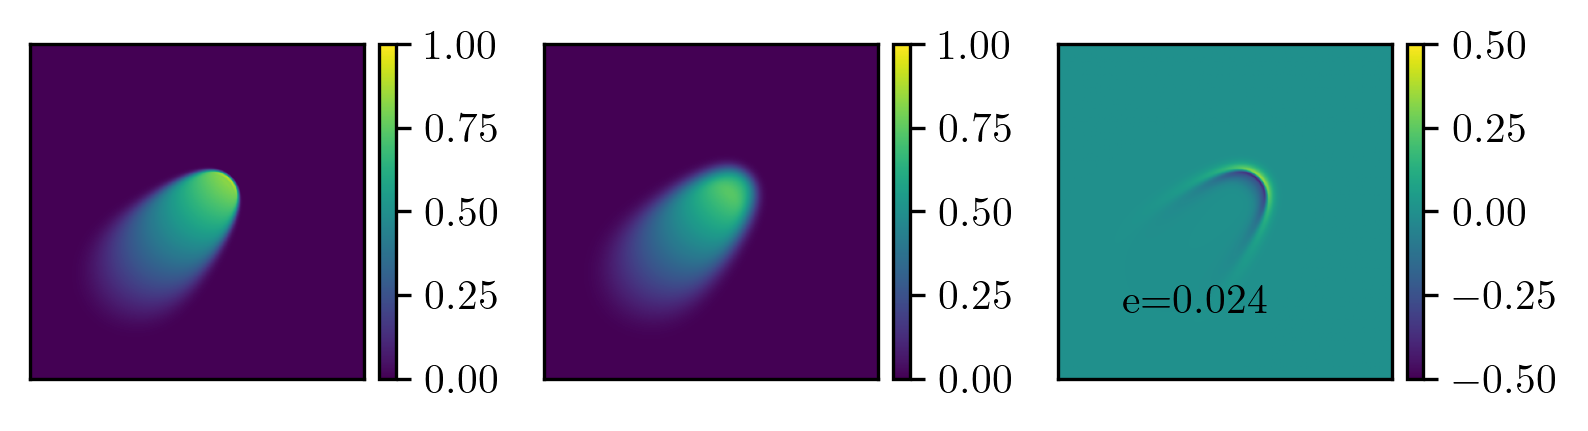

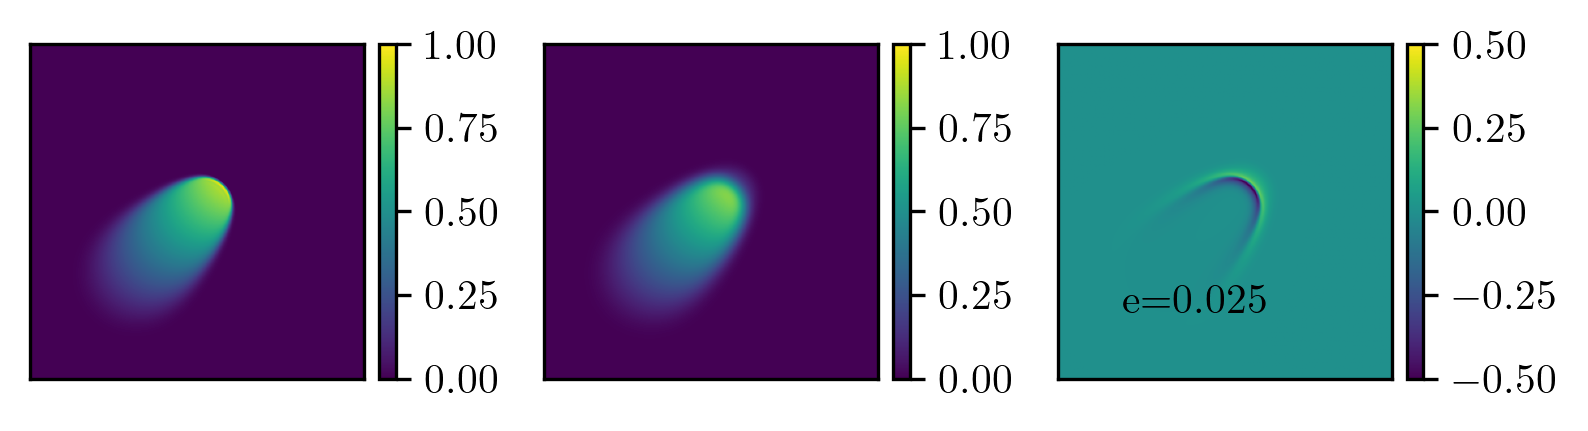

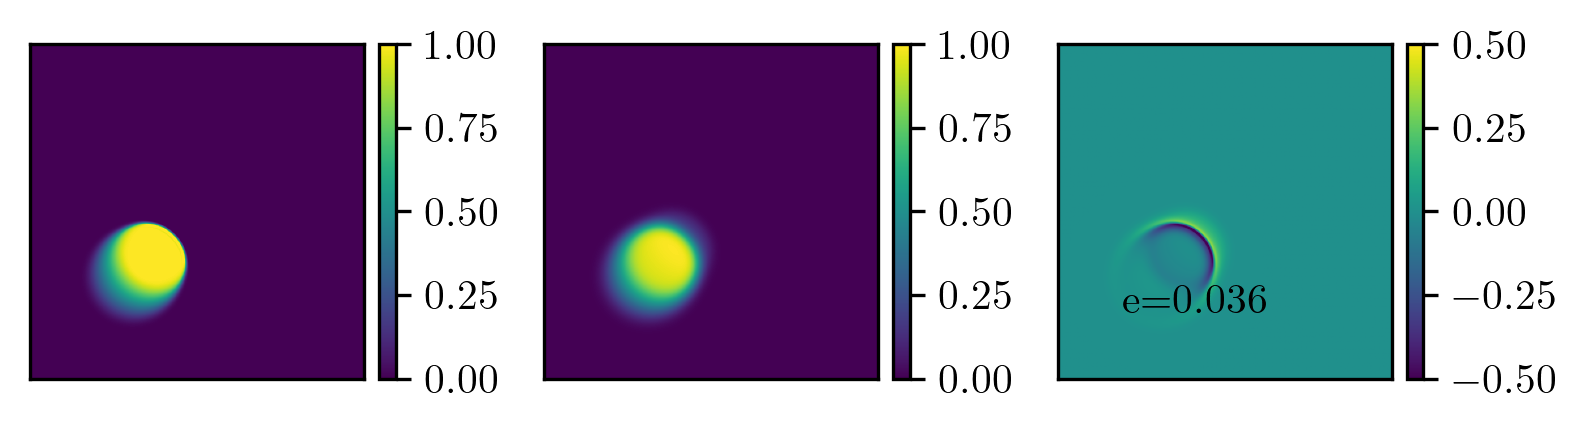

In [53]:
for i in range(len(xi_test[:10])):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(page_width_in, page_width_in/3))
    c1 = ax1.imshow(ground_truth[:, i].reshape(shape), vmin=0, vmax=1, origin="lower")
    c2 = ax2.imshow(smooth_ROM_sharpened[:, i].reshape(shape), vmin=0, vmax=1, origin="lower")
    c3 = ax3.imshow((smooth_ROM_sharpened[:, i]-ground_truth[:, i]).reshape(shape), vmin=-.5, vmax=.5, origin="lower")
    ax3.text(50, 50, "e={:.3f}".format(np.mean((smooth_ROM_sharpened[:, i]-ground_truth[:, i])**2)**.5))
    for ax, cs in zip([ax1, ax2, ax3], [c1, c2, c3]):
        ax.set_xticks([])
        ax.set_yticks([])
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        fig.colorbar(cs, cax=cax)
    plt.show()

In [ ]:
np.linspace(0, 7.5, 76)

# parameter optimization

In [ ]:
shape = int(n**.5), int(n**.5)
X_train = X_all[:, ::p]
t_train = t_all[::p]
X_train_s = np.zeros_like(X_train)


sigmas = np.linspace(0, 5, 51)
sigmas = np.linspace(0, 7, 71)
sigmas = np.linspace(0, 20, 51)
sigmas = np.linspace(0, 10, 41)
sigmas = np.linspace(0, 7.5, 76)
n_sharpenings = [1] # [1, 2, 3]
size_filter = [1, 3, 5, 7, 9, 11]

e2 = np.zeros((len(sigmas),))
e3 = np.zeros((len(sigmas), len(size_filter), len(n_sharpenings)))


for j, sgm in enumerate(sigmas):
    print(sgm)
    for i in range(len(X_train[0])):
        ss2D = X_train[:, i].reshape(shape)
        X_train_s[:, i] = gaussian_filter(ss2D, sigma=sgm, truncate=10).ravel()

    reg = RegularGrid()
    pod = POD(rank=rank)
    db = Database(t_train[:, None], X_train_s.T)
    rom = ROM(db, pod, reg)
    rom.fit()
    smooth_ROM = rom.predict(xi_test).T

    e2[j] = np.mean((smooth_ROM-ground_truth)**2)**.5
    for k, sz in enumerate(size_filter):
        for l, ns in enumerate(n_sharpenings):
            p_sharp = np.zeros_like(ground_truth)
            for i in range(len(xi_test)):
                p_sharp[:, i] = sharpen(smooth_ROM[:, i].copy().reshape(shape), sz, ns)
            #p1 = sharpen(smooth_ROM[:, 0].reshape(shape), ns).ravel()
            #p2 = sharpen(smooth_ROM[:, 1].reshape(shape), ns).ravel()
            #p_sharp = np.c_[p1, p2]
            error_per_ss = np.mean((p_sharp-ground_truth)**2, axis=0)**.5
            e3[j, k, l] = np.mean(error_per_ss)

In [ ]:
#plt.plot(sigmas, e2, label="smooth ROM")
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(sigmas*dx, np.ones_like(e2)*eROM, lw=1, label="standard ROM")
colors = ["C2", "C3", "C4", "C5", "C6"]
marker = [".", "1", "+", "x", "|", "_", "0"]
plt.plot(sigmas*dx, e3[:, 0, 0], "C1--", lw=1, label="$s_k=1$")
for k, sz in enumerate(size_filter):
    #sz = size_filter[k]
    if k in [1, 2, 3, 4]:
        plt.plot(sigmas*dx, e3[:, k, 0], color=colors[k], marker=marker[k], ms=4, ls="-", lw=1, label="$s_k=${:2d}".format(sz))
        #plt.plot(sigmas, e3[:, k, 0], color=colors[k], marker="o", ms=3, ls="-", label="$n_s = ${:2d}$, sz=${:2d}".format(1, sz))
        #plt.plot(sigmas, e3[:, k, 1], color=colors[k], marker="X", ms=3, ls="--", label="$n_s = ${:2d}$, sz=${:2d}".format(2, sz))
        #plt.plot(sigmas, e3[:, k, 2], color=colors[k], marker="+", ms=3, ls=":", label="$n_s = ${:2d}$, sz=${:2d}".format(3, sz))
        ind = np.argmin(e3[:, k, 0])
        print(ind)
        print("size=", sz, "k=",k,"sigma=", sigmas[ind], "ns=", 1, e3[ind, k, 0])
plt.legend()
# plt.ylim([0.015, .025])
# plt.ylim([0.03, .04])
#plt.ylim([0.015, .02])
#plt.ylim([np.min(e3)*0.95, eROM*1.15])
plt.ylim([0.022, .028])
plt.ylim([0.02, .025])
plt.xlim([0, 7.5*dx])
plt.xlabel("$\sigma$")
plt.ylabel("error")
plt.grid()

In [ ]:
# TODO: find the best parameters automatically

In [ ]:

is_ = [14, 15, 16, 17, 18, 19, 20]
print(sigmas[is_] , e3[is_, 3, 0])

In [ ]:
print(sigmas[[17, 18, 19]] , e3[[17, 18, 19], 3, 0])
is_ = [24, 25, 26]
#print(sigmas[is_] , e3[is_, 3, 1])

In [ ]:
# TODO: error vs time
# TODO: sharpening!
# TODO: find best error, correlate with sigma
# 1D case?

In [ ]:
sigma, ns = 4.5, 12  # 1.67
sigma, ns = 3.5, 7  # 3.1
sigma, ns = 3, 5  # 3.05
sigma, ns = 2.5, 4  # 5.5
#sigma, ns = 2, 2  # 2.94
#sigma, ns = 1.75, 1  # -1.4

sigma, ns = 1.3, 1  # 4.5
sigma, ns = 1.8, 2  # 5.2
sigma, ns = 2.2, 3  # 5.5
#sigma, ns = 2.5, 4  # 5.5
#sigma, ns = 2.7, 3  # 5.5
#sigma, ns = 6.25, 2  # 5.5
#sigma, ns = 4.3, 1  # 6.3, sz=5 or 7

sigma, ns, sz = 4.3, 1, 7  # 6.05
#sigma, ns, sz = 4.0, 1, 7  # 6.05  double the snapshots!
sigma, ns, sz = 4.0, 1, 7  # 7.13  nu=1e-3, bis 800
sigma, ns, sz = 4.1, 1, 7  # 7.3  nu=1e-3 bis 1000
#sigma, ns, sz = 6.25, 2, 7

#sigma, ns, sz = 1.6, 1, 3  # 7.3  nu=1e-3 bis 1000


for sigma in [sigma]:  # sigmas
    for i in range(len(X_train[0])):
        ss2D = X_train[:, i].reshape(shape)
        X_train_s[:, i] = gaussian_filter(ss2D, sigma=sigma, truncate=10).ravel()

    reg = RegularGrid()
    pod = POD(rank=rank)
    db = Database(t_train[:, None], X_train.T)
    standard_rom = ROM(db, pod, reg)
    standard_rom.fit()

    reg = RegularGrid()
    pod = POD(rank=rank)
    db = Database(t_train[:, None], X_train_s.T)
    smooth_rom = ROM(db, pod, reg)
    smooth_rom.fit()

    e_t = np.zeros((len(t_all), 3))
    for j, _t_ in enumerate(t_all[t_all<=0.9]):
        xi_val = [_t_]
        _ground_truth = X_all[:, j]
        p_standard_rom = standard_rom.predict(xi_val)
        p_smooth_ROM = smooth_rom.predict(xi_val)

        p_sharp = sharpen(p_smooth_ROM.reshape(shape), sz, ns).ravel()
        e_t[j, 0] = np.mean((p_standard_rom-_ground_truth)**2)**.5
        e_t[j, 1] = np.mean((p_smooth_ROM-_ground_truth)**2)**.5
        e_t[j, 2] = np.mean((p_sharp-_ground_truth)**2)**.5

print(sigma, (1-np.mean(e_t[t_all<=0.9, 2])/np.mean(e_t[t_all<=0.9, 0]))*100, sep="\t")

In [ ]:
for j, _t_ in enumerate(t_all[t_all<=0.9]):
    if _t_ in xi_test:
        print(_t_, e_t[j, 0], e_t[j, 1], e_t[j, 2], sep="\t")

In [ ]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(t_all[:-40], e_t[:-40, 0], markevery=25, marker="+", ms=3, label="standard ROM")
plt.plot(t_all[:-40], e_t[:-40, 1], "C1--", ms=3, label="regularized ROM")
plt.plot(t_all[:-40], e_t[:-40, 2], "C2-", markevery=25, marker="x", ms=3, label="regularized ROM + sharpening")
plt.legend()
plt.xlabel("time")
plt.ylabel("model error")
#print(np.mean(e_t[:-40, 0]))
#print(np.mean(e_t[:-40, 2]))
#print((1-np.mean(e_t[:-40, 2]/e_t[:-40, 0]))*100)
#plt.ylim([0.040, 0.050])
#plt.xlim([0.1, 0.2])
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .07, 8, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.xlim([0., 0.9])
plt.ylim([0.0, 0.07])
plt.show()
print(sigma, ns, sz)
print(np.mean(e_t[t_all<=0.9, 2]), np.mean(e_t[t_all<=0.9, 0]), sep="\t")
print(sigma, (1-np.mean(e_t[t_all<=0.9, 2])/np.mean(e_t[t_all<=0.9, 0]))*100, sep="\t")

In [ ]:
0.010109894838025504/0.009661992233590494

In [ ]:
# 3.9	6.990350788421051
# 4.0	7.2604890517088405
# 4.1	7.326077410310727
# 4.3	6.9250895826791
# 4.5	5.9353519574774305